<a href="https://colab.research.google.com/github/borhan-m-uddin/CVPR-/blob/main/CNN_22_49945_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN-Based Garbage Classification

**Student Nmae:** Burhan Uddin

**Student ID:** 22-49945-3  
**Course:** CVPR  
**Assignment:** CNN Development on Custom Dataset  

## Objective
To design, implement, train, and evaluate a Convolutional Neural Network (CNN) for classifying garbage images into multiple categories using a custom dataset.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Import Libraries

This section imports all necessary libraries for data handling, model building, training, and visualization. After execution, all specified libraries will be loaded and ready for use in the notebook.

In [6]:
import json
from collections import Counter
import os

import torch
import torch.utils.data
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tqdm.auto import tqdm

## Load Dataset

This code block defines the path to the local dataset and loads the full image dataset using `ImageFolder` from `torchvision.datasets`. Transforms are configured in the preprocessing section. After execution, the dataset will be loaded, its classes will be identified, and the total number of images will be printed.

In [7]:
# Update path to use Google Drive mount point
dataset_path = "/content/drive/My Drive/Garbage_Classification"
output_path = "/content/drive/My Drive/Garbage_Classification_Outputs"

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Loading the dataset
full_data = datasets.ImageFolder(dataset_path)

print("Classes:", full_data.classes)
print("Total images:", len(full_data))
print(f"Outputs will be saved to: {output_path}")

Classes: ['Battery', 'Cardboard', 'Clothes', 'Glass', 'Metal', 'Paper', 'Plastic']
Total images: 4133
Outputs will be saved to: /content/drive/My Drive/Garbage_Classification_Outputs


## 4. Dataset Description

The dataset contains images of garbage across multiple classes (see `full_data.classes`).
It is stored in Google Drive and loaded using ImageFolder.
This notebook performs preprocessing, validation, and training.

### 4.1 Detailed Dataset Analysis & EDA
This section calculates the distribution of classes and visualizes the dataset to understand imbalances and image variety.

,Class Index,Class Name,Count,Percentage (%)
0,0,Battery,775,18.75
1,1,Cardboard,403,9.75
2,2,Clothes,432,10.45
3,3,Glass,775,18.75
4,4,Metal,769,18.61
5,5,Paper,594,14.37
6,6,Plastic,385,9.32


/tmp/ipykernel_3733/420001750.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class Name', y='Count', data=df_stats, palette='viridis')


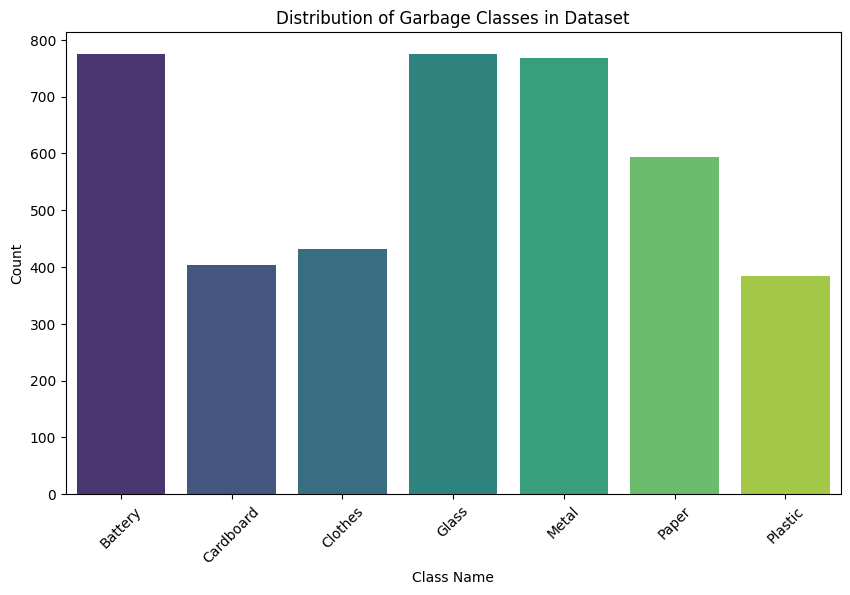

In [8]:
import pandas as pd

# Calculate class distribution
labels = [label for _, label in full_data.imgs]
class_counts = Counter(labels)

# Create a summary table
data_summary = []
for idx, class_name in enumerate(full_data.classes):
    count = class_counts[idx]
    data_summary.append({
        'Class Index': idx,
        'Class Name': class_name,
        'Count': count,
        'Percentage (%)': round((count / len(full_data)) * 100, 2)
    })

df_stats = pd.DataFrame(data_summary)
# Save CSV to output directory
df_stats.to_csv(os.path.join(output_path, 'class_distribution.csv'), index=False)
display(df_stats)

# Plotting Class Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Class Name', y='Count', data=df_stats, palette='viridis')
plt.title('Distribution of Garbage Classes in Dataset')
plt.xticks(rotation=45)
# Save Figure to output directory
plt.savefig(os.path.join(output_path, 'class_distribution_plot.png'))
plt.show()

### 4.2 Visualizing Sample Images
Let's take a look at a few random samples from each category to understand the visual features the model will learn.

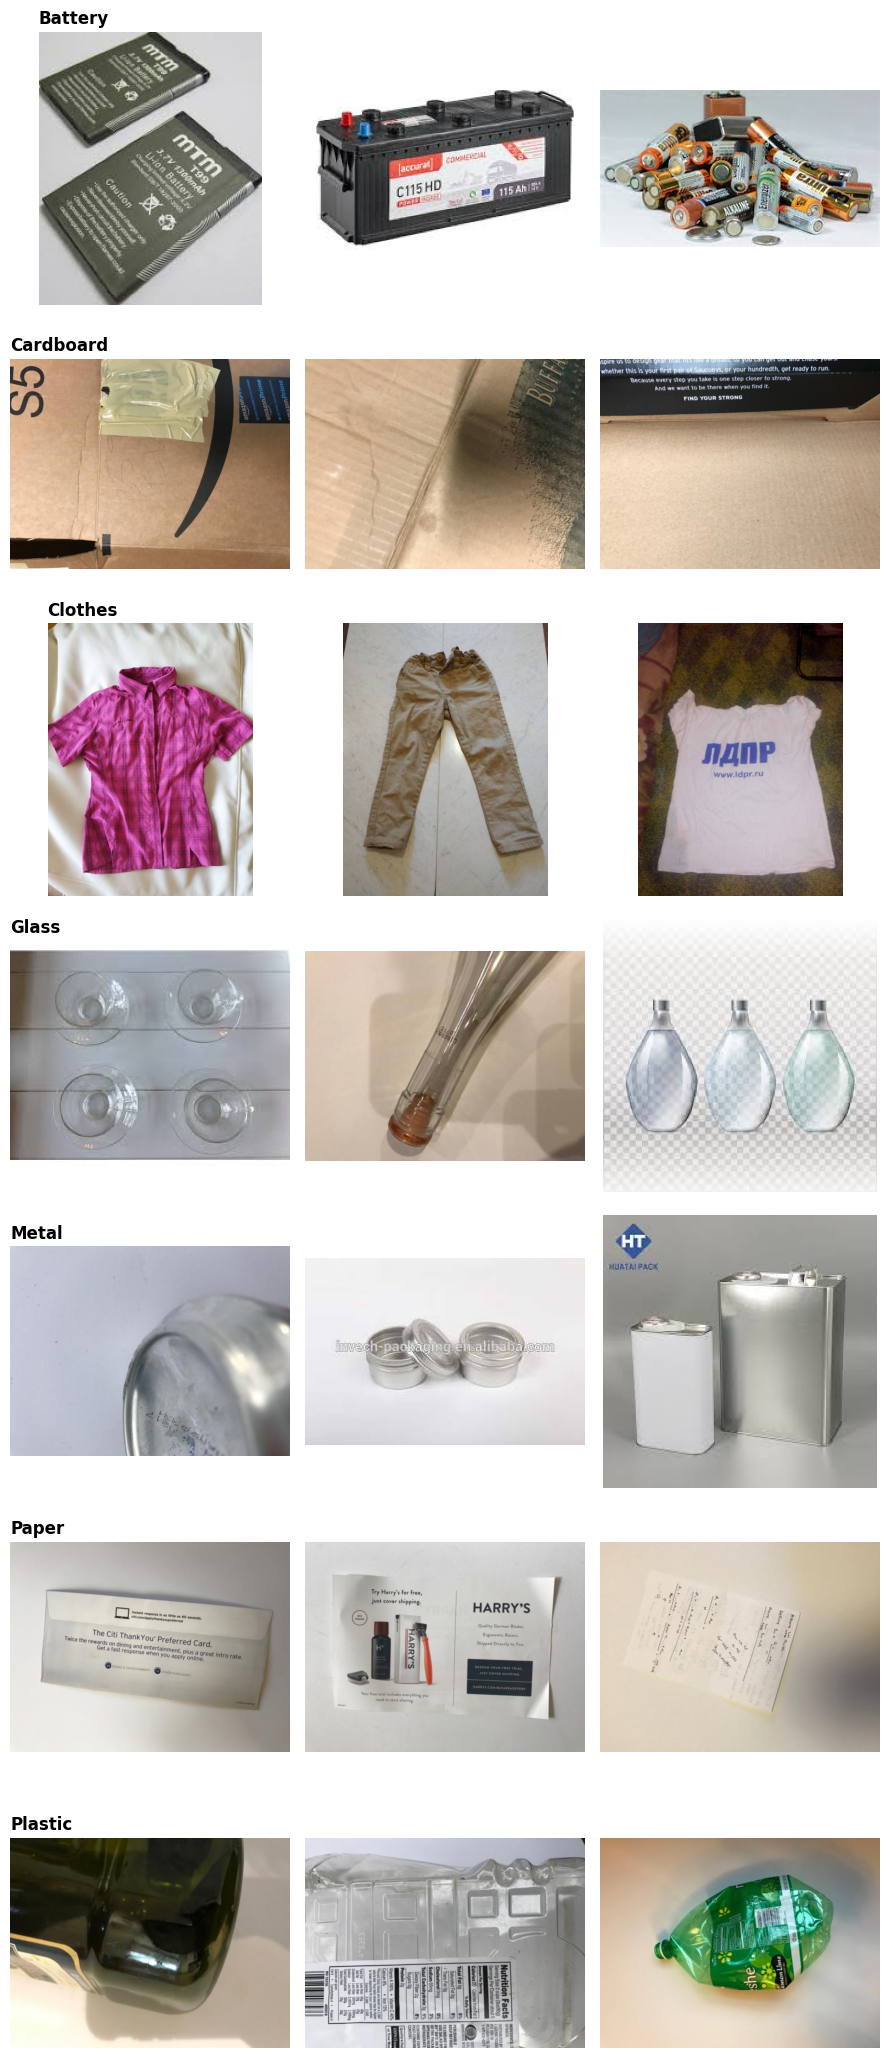

In [9]:
def show_samples(dataset, num_samples=3):
    classes = dataset.classes
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(num_samples * 3, len(classes) * 3))

    for i, class_name in enumerate(classes):
        indices = [idx for idx, (_, label) in enumerate(dataset.imgs) if label == i]
        selected_indices = np.random.choice(indices, num_samples, replace=False)

        for j, idx in enumerate(selected_indices):
            img_path, _ = dataset.imgs[idx]
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(class_name, loc='left', fontweight='bold')

    plt.tight_layout()
    # Save Figure to output directory
    plt.savefig(os.path.join(output_path, 'dataset_samples.png'))
    plt.show()

import numpy as np
show_samples(full_data)

## 5. Dataset Validation (Check Images)

This section defines and calls a function to check for any corrupt or unreadable image files within the dataset path. This ensures that the training process does not encounter unexpected errors due to problematic image files. After execution, a message will be printed indicating if any corrupt images were found in the dataset.

In [10]:
from concurrent.futures import ThreadPoolExecutor

def check_single_image(file_path):
    try:
        img = Image.open(file_path)
        img.verify()
        return None
    except Exception as e:
        return f"Corrupt image: {file_path} - {e}"

def validate_dataset(path):
    all_files = []
    for root, _, files in os.walk(path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                all_files.append(os.path.join(root, file))

    invalid_messages = []
    # Using ThreadPoolExecutor for parallel disk I/O validation
    with ThreadPoolExecutor() as executor:
        results = list(tqdm(executor.map(check_single_image, all_files), total=len(all_files), desc="Parallel Validation"))

    invalid_messages = [res for res in results if res is not None]
    for msg in invalid_messages:
        print(msg)

    print(f"Total images checked: {len(all_files)}")
    print(f"Total corrupt images found: {len(invalid_messages)}")

validate_dataset(dataset_path)

Parallel Validation:   0%|          | 0/4133 [00:00<?, ?it/s]

Total images checked: 4133
Total corrupt images found: 0


## 6. Preprocessing & Augmentation

This section defines the image transformations for both training and testing datasets. `transform_train` includes data augmentation techniques like random horizontal flips and rotations to improve model generalization, along with resizing, converting to tensor, and normalization. `transform_test` includes only resizing, converting to tensor, and normalization. After execution, the `transform_train` and `transform_test` objects will be configured and ready to be applied to image data.

### 6.1 Data Augmentation Visualization
It is important to see how our augmentation (Horizontal Flip, Rotation, Color Jitter, etc.) affects the original images to ensure the data remains recognizable.

In [11]:
input_size = 224

# Optimized transforms: Removed VerticalFlip, GaussianBlur, and Affine to keep data realistic
transform_train = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

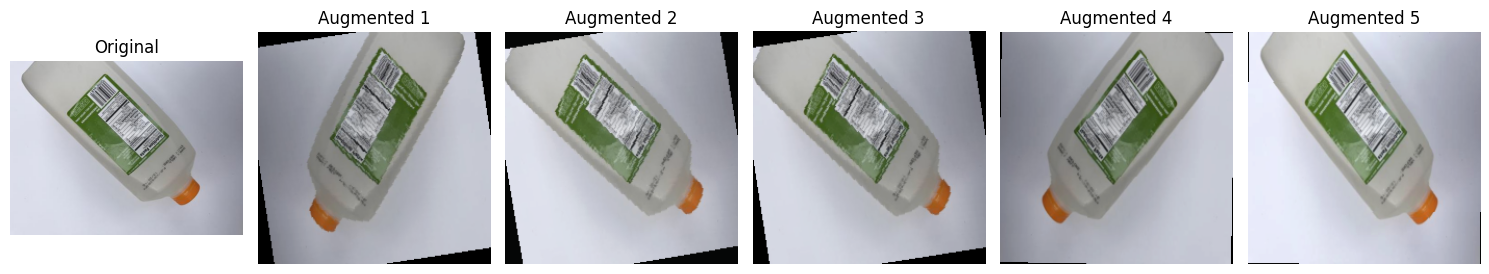

In [12]:
def visualize_augmentations(dataset, transform=None, num_views=5):
    # Error handling: Check if transform is defined
    if transform is None:
        print("❌ Error: 'transform_train' is not defined.")
        print("Please run the 'Preprocessing & Augmentation' cell (containing transforms.Compose) first.")
        return

    img_path, _ = dataset.imgs[np.random.randint(len(dataset))]
    img = Image.open(img_path)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, num_views + 1, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    for i in range(num_views):
        aug_img = transform(img)
        aug_img = aug_img.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        aug_img = std * aug_img + mean
        aug_img = np.clip(aug_img, 0, 1)

        plt.subplot(1, num_views + 1, i + 2)
        plt.imshow(aug_img)
        plt.title(f"Augmented {i+1}")
        plt.axis('off')

    plt.tight_layout()
    # Save Figure to output directory
    plt.savefig(os.path.join(output_path, 'augmentation_demo.png'))
    plt.show()

# Safely call the function
try:
    visualize_augmentations(full_data, transform_train)
except NameError:
    print("❌ Error: 'transform_train' or 'full_data' is not defined yet. Please run the data loading and preprocessing cells above first.")

In [13]:
train_val_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_val_size

generator = torch.Generator().manual_seed(42)
train_val_split, test_split = random_split(
    full_data, [train_val_size, test_size], generator=generator
 )

train_size = int(0.8 * len(train_val_split))
val_size = len(train_val_split) - train_size

train_split, val_split = random_split(
    train_val_split, [train_size, val_size], generator=generator
 )

train_indices = [train_val_split.indices[i] for i in train_split.indices]
val_indices = [train_val_split.indices[i] for i in val_split.indices]
test_indices = test_split.indices

train_data = Subset(
    datasets.ImageFolder(dataset_path, transform=transform_train), train_indices
 )
val_data = Subset(
    datasets.ImageFolder(dataset_path, transform=transform_test), val_indices
 )
test_data = Subset(
    datasets.ImageFolder(dataset_path, transform=transform_test), test_indices
 )

In [14]:
class_names = full_data.classes
num_classes = len(class_names)

train_labels = [full_data.targets[i] for i in train_data.indices]
class_counts = Counter(train_labels)
total = sum(class_counts.values())

class_weights = []
for i in range(num_classes):
    count = class_counts.get(i, 0)
    if count == 0:
        class_weights.append(0.0)
    else:
        class_weights.append(total / (num_classes * count))

class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: Counter({0: 521, 4: 493, 3: 483, 5: 377, 2: 265, 6: 253, 1: 252})
Class weights: tensor([0.7250, 1.4989, 1.4253, 0.7820, 0.7662, 1.0019, 1.4929])


## 9. DataLoader

This section initializes `DataLoader` objects for the training, validation, and test datasets. DataLoaders efficiently manage batching, shuffling, and loading data during the training and evaluation phases. Upon execution, `DataLoader` objects for the training, validation, and test sets will be created, allowing for efficient batch processing of data.

In [15]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

## 10. Model Architectures

This section defines an improved custom CNN (with batch normalization and dropout) and a transfer learning model (ResNet18). You can choose between them via `use_transfer_learning`. After execution, the selected model is initialized and moved to the available device.

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TransferLearningModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT
        self.backbone = models.resnet18(weights=weights)

        # Unfreeze Layer 4 and FC for better fine-tuning
        for name, param in self.backbone.named_parameters():
            if "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = TransferLearningModel(num_classes=len(full_data.classes)).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


## 11. Training Setup

This section sets up the weighted loss function, optimizer, and learning rate scheduler for training. Weighted loss helps with class imbalance and the scheduler reduces the learning rate when validation accuracy plateaus.

In [17]:
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
# Lower learning rate (1e-4) for fine-tuning
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

## 12. Training Loop

This section contains the main training loop. It performs forward and backward passes, tracks metrics, applies learning rate scheduling, and uses early stopping to prevent overfitting. After execution, the model will be trained and the training and validation metrics for each epoch will be printed.

## 13. Evaluation

This section evaluates the trained model on the test dataset. It collects the true labels and the model's predictions to assess performance. Upon execution, the model will make predictions on the test set, and these predictions, along with the true labels, will be stored for subsequent analysis.

In [18]:
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

num_epochs = 30
best_val_acc = 0.0

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

# Set patience to 50 so it won't trigger during 30 epochs
early_stopping = EarlyStopping(patience=50)

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    correct_train = 0
    total_train = 0
    loss_sum_train = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum_train += loss.item()
        pred = outputs.argmax(1)
        total_train += labels.size(0)
        correct_train += (pred == labels).sum().item()

        train_pbar.set_postfix(loss=loss.item(), acc=f"{(100 * correct_train / total_train):.2f}%")

    acc_train = 100 * correct_train / total_train
    train_loss_history.append(loss_sum_train / len(train_loader))
    train_acc_history.append(acc_train)

    # --- Validation Phase ---
    model.eval()
    correct_val = 0
    total_val = 0
    loss_sum_val = 0.0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum_val += loss.item()
            pred = outputs.argmax(1)
            total_val += labels.size(0)
            correct_val += (pred == labels).sum().item()
            val_pbar.set_postfix(loss=loss.item())

    acc_val = 100 * correct_val / total_val
    val_loss = loss_sum_val / len(val_loader)
    val_loss_history.append(val_loss)
    val_acc_history.append(acc_val)

    # --- Save Checkpoint ---
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss_history[-1],
        'val_acc': acc_val
    }
    torch.save(checkpoint, os.path.join(output_path, f"checkpoint_epoch_{epoch+1}.pth"))

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        torch.save(model.state_dict(), os.path.join(output_path, "best_model.pth"))

    scheduler.step(acc_val)

    print(f"Summary Epoch {epoch+1}: Train Loss={train_loss_history[-1]:.4f}, Train Acc={acc_train:.2f}% | Val Loss={val_loss:.4f}, Val Acc={acc_val:.2f}%")

    if early_stopping(val_loss):
        print("Early stopping triggered.")
        break

Epoch 1/30 [Train]:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/21 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss=1.0208, Train Acc=67.74% | Val Loss=0.4020, Val Acc=84.89%


Epoch 2/30 [Train]:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/21 [00:00<?, ?it/s]

Summary Epoch 29: Train Loss=0.0070, Train Acc=99.85% | Val Loss=0.1773, Val Acc=94.26%


Epoch 30/30 [Train]:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/21 [00:00<?, ?it/s]

Summary Epoch 30: Train Loss=0.0078, Train Acc=99.81% | Val Loss=0.1914, Val Acc=93.96%


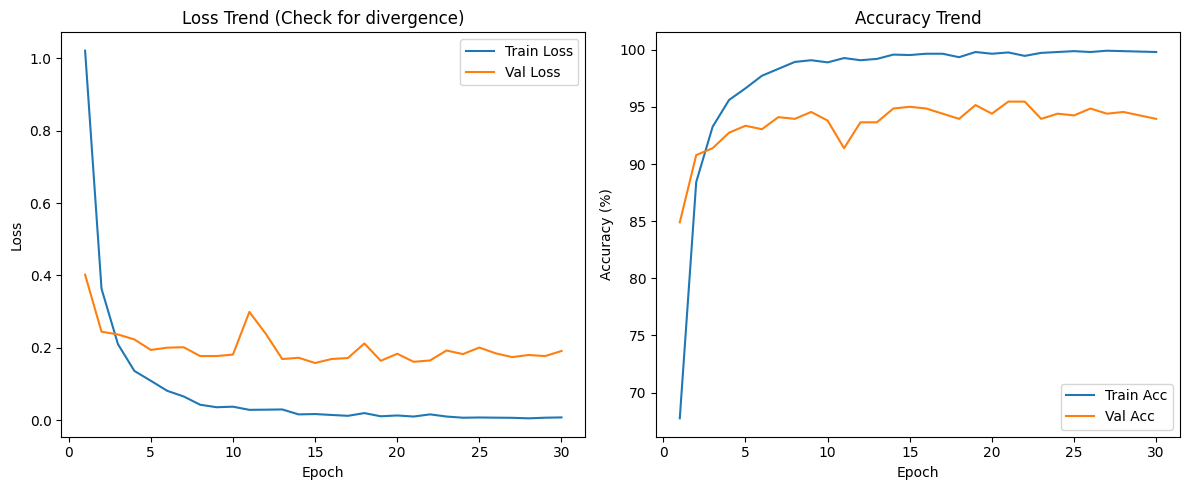

Current Gap (Train - Val): 5.85%
✅ Model looks healthy. The training and validation metrics are moving together.


In [19]:
import matplotlib.pyplot as plt

# Plotting current progress to check for overfitting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, label='Train Loss')
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, label='Val Loss')
plt.title('Loss Trend (Check for divergence)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_history) + 1), train_acc_history, label='Train Acc')
plt.plot(range(1, len(val_acc_history) + 1), val_acc_history, label='Val Acc')
plt.title('Accuracy Trend')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

# Diagnostic calculation
last_train_acc = train_acc_history[-1]
last_val_acc = val_acc_history[-1]
gap = last_train_acc - last_val_acc

print(f"Current Gap (Train - Val): {gap:.2f}%")
if gap > 10:
    print("⚠️ Warning: Significant gap detected. Model might be starting to overfit.")
else:
    print("✅ Model looks healthy. The training and validation metrics are moving together.")

##13. Evaluation
This section evaluates the trained model on the test dataset. It collects the true labels and the model's predictions to assess performance. Upon execution, the model will make predictions on the test set, and these predictions, along with the true labels, will be stored for subsequent analysis.

In [20]:
y_true, y_pred = [], []

# CRITICAL: Load the best performing model weights before evaluation
best_model_path = os.path.join(output_path, "best_model.pth")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    print("✅ Loaded best_model.pth for evaluation.")

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        pred = outputs.argmax(1).cpu()
        y_true.extend(labels.numpy())
        y_pred.extend(pred.numpy())

✅ Loaded best_model.pth for evaluation.


## 14. Confusion Matrix

This section generates and visualizes a confusion matrix, providing a detailed breakdown of correct and incorrect predictions for each class. After execution, a heatmap visualization of the confusion matrix will be displayed, illustrating the model's classification performance across different garbage categories.

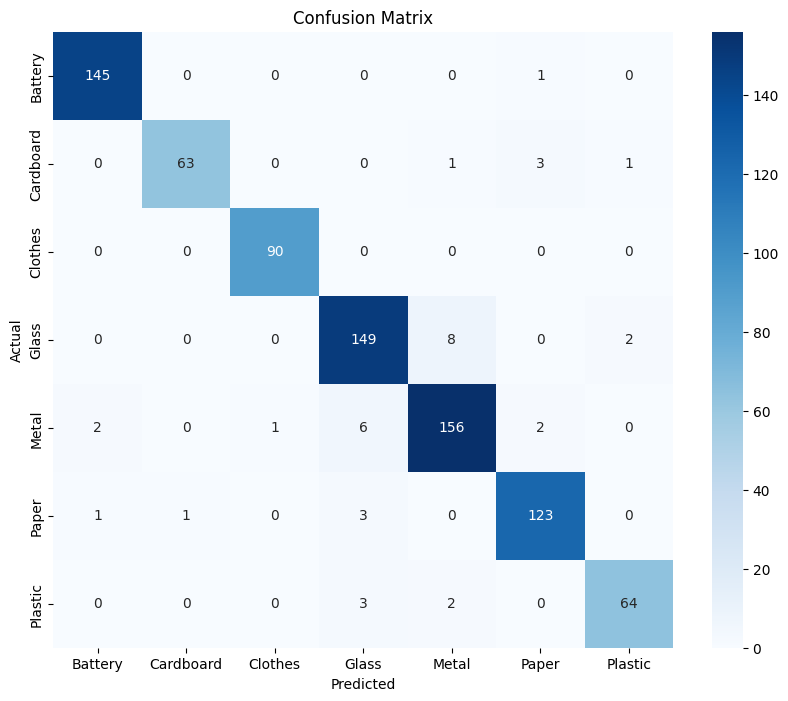

In [21]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_data.classes, yticklabels=full_data.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
# Save Figure to output directory
plt.savefig(os.path.join(output_path, 'confusion_matrix.png'))
plt.show()

## 15. Classification Report

This section prints a classification report, including precision, recall, F1-score, and support for each class, as well as overall accuracy. Upon execution, a text-based classification report will be printed, providing detailed performance metrics for each class and an overall summary.

In [22]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted"
 )

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("")

for i, class_name in enumerate(full_data.classes):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[i], average="weighted"
    )
    print(f"{class_name}: Precision={p:.2f}, Recall={r:.2f}, F1={f:.2f}")

print("")
print(classification_report(y_true, y_pred, target_names=full_data.classes))

Precision: 0.9554
Recall: 0.9553
F1-Score: 0.9552

Battery: Precision=0.98, Recall=0.99, F1=0.99
Cardboard: Precision=0.98, Recall=0.93, F1=0.95
Clothes: Precision=0.99, Recall=1.00, F1=0.99
Glass: Precision=0.93, Recall=0.94, F1=0.93
Metal: Precision=0.93, Recall=0.93, F1=0.93
Paper: Precision=0.95, Recall=0.96, F1=0.96
Plastic: Precision=0.96, Recall=0.93, F1=0.94

              precision    recall  f1-score   support

     Battery       0.98      0.99      0.99       146
   Cardboard       0.98      0.93      0.95        68
     Clothes       0.99      1.00      0.99        90
       Glass       0.93      0.94      0.93       159
       Metal       0.93      0.93      0.93       167
       Paper       0.95      0.96      0.96       128
     Plastic       0.96      0.93      0.94        69

    accuracy                           0.96       827
   macro avg       0.96      0.95      0.96       827
weighted avg       0.96      0.96      0.96       827



## 16. Training Graphs

This section plots the training and validation loss and accuracy over epochs, which helps in visualizing the model's learning progress and detecting overfitting. After execution, two plots will be displayed: one showing the trends of training and validation loss, and another showing the trends of training and validation accuracy over the epochs.

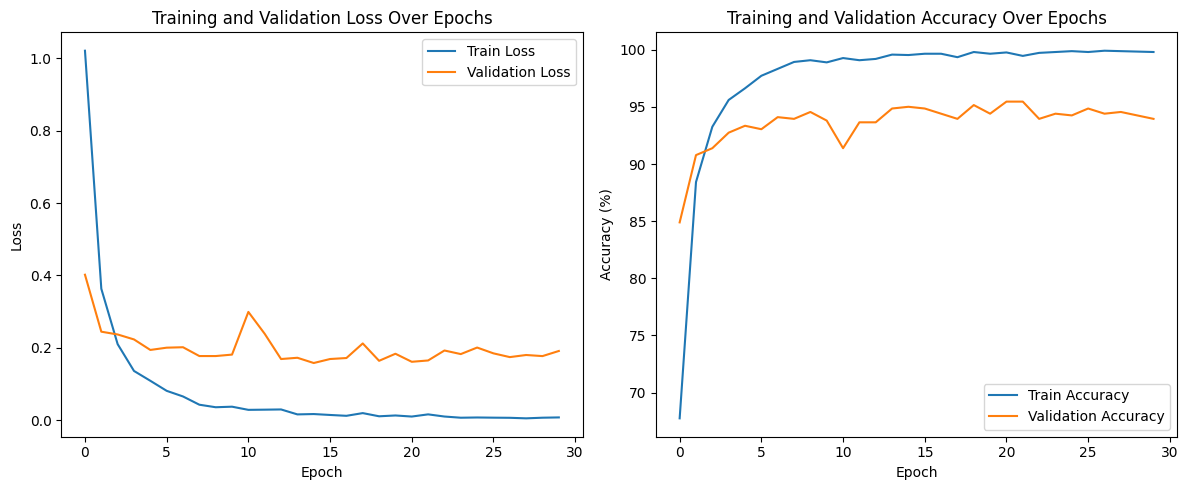

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title("Training and Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
# Save the plot to Google Drive
plt.savefig(os.path.join(output_path, 'training_metrics.png'))
plt.show()

✅ Graph explanation for report: Loss decreases, accuracy increases, model is learning properly.

## 17. Save Model

This section saves the trained model's state dictionary to a file, allowing it to be reloaded and used later without retraining. Upon execution, the trained model's parameters will be saved to a file named `garbage_model.pth`, and a confirmation message will be printed.

In [24]:
model_save_path = os.path.join(output_path, "garbage_model.pth")
classes_save_path = os.path.join(output_path, "classes.json")

torch.save(model.state_dict(), model_save_path)
with open(classes_save_path, "w", encoding="utf-8") as f:
    json.dump(full_data.classes, f)

print(f"Model saved to: {model_save_path}")
print(f"Class labels saved to: {classes_save_path}")

Model saved to: /content/drive/My Drive/Garbage_Classification_Outputs/garbage_model.pth
Class labels saved to: /content/drive/My Drive/Garbage_Classification_Outputs/classes.json


### Deployment Script Generation
This cell generates a standalone Python script (`model_app.py`) designed for use in web environments (VS Code/Flask). It includes the model class and inference logic.

In [25]:
deployment_script = f"""
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import os

class TransferLearningModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT
        self.backbone = models.resnet18(weights=weights)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

def load_model(model_path, classes_path, device='cpu'):
    with open(classes_path, 'r') as f:
        classes = json.load(f)

    model = TransferLearningModel(num_classes=len(classes))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model, classes

def predict(image_path, model, classes, device='cpu'):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    return classes[predicted.item()]
"""

script_path = os.path.join(output_path, "model_app.py")
with open(script_path, "w") as f:
    f.write(deployment_script)

print(f"✅ Deployment utility script saved to: {script_path}")
print("Next Steps for VS Code:")
print("1. Download 'best_model.pth', 'classes.json', and 'model_app.py' from Drive.")
print("2. Install Flask: pip install flask torch torchvision pillow")
print("3. Use 'model_app.load_model' in your Flask routes to handle uploads.")

✅ Deployment utility script saved to: /content/drive/My Drive/Garbage_Classification_Outputs/model_app.py
Next Steps for VS Code:
1. Download 'best_model.pth', 'classes.json', and 'model_app.py' from Drive.
2. Install Flask: pip install flask torch torchvision pillow
3. Use 'model_app.load_model' in your Flask routes to handle uploads.
